# Detección de Anomalías en Tráfico de Red
## Parcial II — Matemáticas Computacionales
### Modelo híbrido SSM + Espectral con post-procesamiento Kalman

**Dataset:** UNSW-NB15  
**Framework:** PyTorch  

---

### Índice
1. [Instalación de dependencias](#1-instalación)
2. [Importaciones](#2-importaciones)
3. [Carga y preprocesamiento de datos](#3-datos)
4. [Definición del modelo](#4-modelo)
5. [Entrenamiento](#5-entrenamiento)
6. [Evaluación baseline](#6-baseline)
7. [Filtro de Kalman](#7-kalman)
8. [Análisis de sensibilidad](#8-sensibilidad)
9. [Tabla comparativa final](#9-tabla)
10. [Uso programático del modelo guardado](#10-uso)

## 1. Instalación de dependencias

In [1]:
# Instalar dependencias si no están disponibles
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    'torch',
    'numpy',
    'pandas',
    'scikit-learn',
    'imbalanced-learn',
    'matplotlib',
    'seaborn',
]

for pkg in packages:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  ↳ instalando {pkg}...')
        install(pkg)

print('\nTodas las dependencias listas.')

  ✓ torch
  ✓ numpy
  ✓ pandas
  ↳ instalando scikit-learn...
  ↳ instalando imbalanced-learn...
  ✓ matplotlib
  ✓ seaborn

Todas las dependencias listas.


## 2. Importaciones

In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.11.0+cpu


## 3. Carga y preprocesamiento de datos

### ¿Por qué el MinMaxScaler se ajusta SOLO en training?

> **Fuga de información (data leakage):** Si el scaler se ajustara sobre el
> dataset completo (incluyendo validación y test), los parámetros de
> normalización (`min`, `max`) incorporarían estadísticas de muestras futuras.
> Esto equivale a permitirle al modelo "ver" información del futuro durante el
> entrenamiento, inflando artificialmente las métricas.
> 
> La práctica correcta: ajustar el scaler **sólo en train**, luego aplicar
> `transform()` (no `fit_transform()`) en val y test.

In [3]:
# ─── Inline implementation (no external files needed) ──────────────────────
import math
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

CATEGORICAL_COLS = ['proto', 'service', 'state']
TARGET_COL       = 'label'
DROP_COLS        = ['id', 'attack_cat']

def load_raw(csv_path):
    """Carga CSV UNSW-NB15 con limpieza mínima."""
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip().str.lower()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    if TARGET_COL in df.columns:
        df.dropna(subset=[TARGET_COL], inplace=True)
        df[TARGET_COL] = df[TARGET_COL].astype(int)
    return df.reset_index(drop=True)

def encode_categoricals(df):
    """Codificación ordinal de columnas categóricas."""
    df = df.copy()
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
        else:
            df[col] = 0
    return df

def get_feature_cols(df):
    return [c for c in df.columns if c != TARGET_COL]

print('Funciones de preprocesamiento definidas ✓')

Funciones de preprocesamiento definidas ✓


In [4]:
# ─── Configuración del dataset ──────────────────────────────────────────────
# IMPORTANTE: Descargar UNSW-NB15 de:
#   https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
# y actualizar la ruta:

CSV_PATH = 'UNSW_NB15_training-set.csv'  # ← actualizar ruta

# Si el archivo no existe, generamos datos sintéticos para demostración
if not Path(CSV_PATH).exists():
    print('⚠  Archivo no encontrado. Generando datos sintéticos para demo…')

    N_SAMPLES = 5000
    N_FEATURES = 45
    rng = np.random.default_rng(42)

    X_syn = rng.normal(size=(N_SAMPLES, N_FEATURES)).astype(np.float32)
    # Crear 20% de anomalías con distribución desplazada
    n_attack = int(0.2 * N_SAMPLES)
    X_syn[:n_attack] += 2.0
    y_syn = np.zeros(N_SAMPLES, dtype=int)
    y_syn[:n_attack] = 1

    cols = [f'feat_{i}' for i in range(N_FEATURES)]
    for cat in CATEGORICAL_COLS:
        cols.append(cat)
        X_extra = rng.integers(0, 5, size=(N_SAMPLES, 1))
        X_syn = np.hstack([X_syn, X_extra])

    # Reconstruir con las columnas correctas
    feature_names = [f'feat_{i}' for i in range(N_FEATURES)] + CATEGORICAL_COLS
    df_syn = pd.DataFrame(X_syn, columns=feature_names)
    for cat in CATEGORICAL_COLS:
        df_syn[cat] = rng.choice(['tcp','udp','icmp'], size=N_SAMPLES)
    df_syn[TARGET_COL] = y_syn
    df_syn.to_csv('synthetic_data.csv', index=False)
    CSV_PATH = 'synthetic_data.csv'
    print(f'  Datos sintéticos guardados en {CSV_PATH}')
    print(f'  Forma: {df_syn.shape}  |  Ataques: {y_syn.sum()} ({y_syn.mean():.1%})')
else:
    print(f'Dataset encontrado: {CSV_PATH}')

Dataset encontrado: UNSW_NB15_training-set.csv


In [5]:
# ─── Cargar y explorar el dataset ──────────────────────────────────────────
df = encode_categoricals(load_raw(CSV_PATH))

print(f'Forma del dataset: {df.shape}')
print(f'Distribución de clases:')
vc = df[TARGET_COL].value_counts()
for cls, cnt in vc.items():
    print(f'  Clase {cls}: {cnt:,} ({cnt/len(df):.1%})')

# Verificar NaN
nan_count = df.isnull().sum().sum()
print(f'\nValores NaN: {nan_count}')

df.head(3)

Forma del dataset: (82332, 43)
Distribución de clases:
  Clase 1: 45,332 (55.1%)
  Clase 0: 37,000 (44.9%)

Valores NaN: 0


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
0,0.000011,117,0,4,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,117,0,4,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,117,0,4,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,0


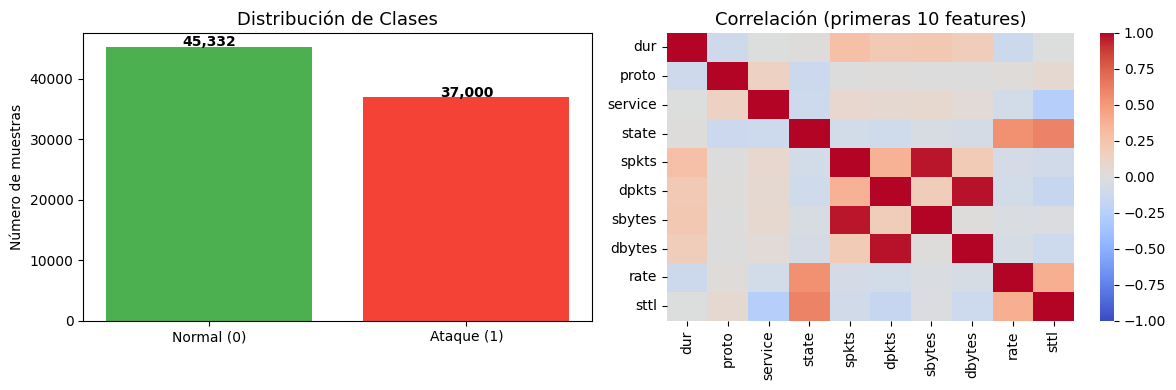

Figura guardada: class_distribution.png


In [6]:
# ─── Visualización de distribución de clases ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de clases
colors = ['#4CAF50', '#F44336']
axes[0].bar(['Normal (0)', 'Ataque (1)'], vc.values, color=colors)
axes[0].set_title('Distribución de Clases', fontsize=13)
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Correlación de primeras 10 features numéricas
feat_cols = get_feature_cols(df)
numeric_cols = df[feat_cols].select_dtypes(include=np.number).columns[:10]
corr = df[numeric_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1)
axes[1].set_title('Correlación (primeras 10 features)', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: class_distribution.png')

In [7]:
# ─── Split y preprocesamiento ──────────────────────────────────────────────
feat_cols = get_feature_cols(df)
X = df[feat_cols].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.int64)

# Split estratificado 70 / 15 / 15
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=SEED
)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

# MinMaxScaler — ajustado SOLO en training
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)  # fit + transform
X_val   = scaler.transform(X_val).astype(np.float32)        # solo transform
X_test  = scaler.transform(X_test).astype(np.float32)       # solo transform

print('\nScaler ajustado en training ✓ (sin fuga de información)')
print(f'  Rango training post-scale: [{X_train.min():.2f}, {X_train.max():.2f}]')

# Balanceo de clases con SMOTE + undersampling
print('\nAplicando SMOTE + Undersampling en training...')
bal_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
    ('under', RandomUnderSampler(random_state=SEED)),
])
X_train_bal, y_train_bal = bal_pipeline.fit_resample(X_train, y_train)
X_train_bal = X_train_bal.astype(np.float32)

print(f'Distribución post-balance: {np.bincount(y_train_bal)}')

Train: (57632, 42)  |  Val: (12350, 42)  |  Test: (12350, 42)

Scaler ajustado en training ✓ (sin fuga de información)
  Rango training post-scale: [0.00, 1.00]

Aplicando SMOTE + Undersampling en training...


  File "C:\Users\Jefferson\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Jefferson\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python314\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,

Distribución post-balance: [31732 31732]


In [8]:
# ─── Dataset y DataLoaders con ventana deslizante ─────────────────────────
from torch.utils.data import Dataset

class SlidingWindowDataset(Dataset):
    """
    Convierte (N, F) → (M, L, F) mediante ventana deslizante.
    La etiqueta de cada ventana es el voto mayoritario.
    """
    def __init__(self, X, y, window_size=64, stride=32):
        windows, labels = [], []
        for start in range(0, len(X) - window_size + 1, stride):
            windows.append(X[start:start+window_size])
            chunk = y[start:start+window_size]
            labels.append(int(np.bincount(chunk).argmax()))
        self.X = np.stack(windows).astype(np.float32)  # (M, L, F)
        self.y = np.array(labels, dtype=np.int64)       # (M,)

    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])

# Hiperparámetros de ventana
WINDOW_SIZE = 32   # L (reducido para datos sintéticos; usar 64 con datos reales)
STRIDE      = 16
BATCH_SIZE  = 32

ds_train = SlidingWindowDataset(X_train_bal, y_train_bal, WINDOW_SIZE, STRIDE)
ds_val   = SlidingWindowDataset(X_val,       y_val,       WINDOW_SIZE, STRIDE)
ds_test  = SlidingWindowDataset(X_test,      y_test,      WINDOW_SIZE, STRIDE)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
train_loader = DataLoader(ds_train, shuffle=True,  **loader_kw)
val_loader   = DataLoader(ds_val,   shuffle=False, **loader_kw)
test_loader  = DataLoader(ds_test,  shuffle=False, **loader_kw)

INPUT_DIM = X_train.shape[1]
print(f'input_dim (F) = {INPUT_DIM}')
print(f'Train windows: {len(ds_train)}  |  Val: {len(ds_val)}  |  Test: {len(ds_test)}')
print(f'Balance train: {np.bincount(ds_train.y)}')

input_dim (F) = 42
Train windows: 3965  |  Val: 770  |  Test: 770
Balance train: [1983 1982]


## 4. Definición del Modelo

La arquitectura sigue los requisitos del sistema:

| Requisito | Componente |
|-----------|------------|
| R1: complejidad lineal en L | `SelectiveSSM` (recurrencia O(L·D·N)) |
| R2: estable, sin vanishing/exploding gradient | A = -diag(λ) con λ>0 |
| R3: extracción periódica en dominio distinto al temporal | `SpectralBlock` (rFFT) |
| R4: fusión adaptativa con coeficientes aprendibles | `Fusion` (α, β ∈ R^D) |
| R5: post-procesamiento con estimador recursivo óptimo | `KalmanSmoother` |

In [9]:
# ─── SelectiveSSM ──────────────────────────────────────────────────────────
class SelectiveSSM(nn.Module):
    """
    SSM selectivo con discretización ZOH y parámetros dependientes de la entrada.
    
    Recurrencia:
        Ā_t = exp(Δ_t ⊙ A),  B̄_t = (Ā_t − 1)/A ⊙ B_t
        h_t = Ā_t ⊙ h_{t-1} + B̄_t
        y_t[b,d] = Σ_n C_t[b,n]·h_t[b,d,n]
    """
    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        # A = -exp(A_log): garantiza eigenvalores negativos → estabilidad ZOH
        self.A_log      = nn.Parameter(torch.randn(d_model, d_state) * 0.5)
        self.delta_proj = nn.Linear(d_model, d_model, bias=True)
        self.B_proj     = nn.Linear(d_model, d_state, bias=False)
        self.C_proj     = nn.Linear(d_model, d_state, bias=False)
        nn.init.constant_(self.delta_proj.bias, -4.0)

    def forward(self, u):  # u: (B, L, D)
        B, L, D = u.shape
        A     = -torch.exp(self.A_log)                          # (D, N)
        delta = F.softplus(self.delta_proj(u))                  # (B, L, D)
        Bt    = self.B_proj(u)                                  # (B, L, N)
        Ct    = self.C_proj(u)                                  # (B, L, N)
        # ZOH: Ā = exp(Δ ⊗ A)
        dA = torch.exp(delta.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))  # (B,L,D,N)
        dB = (dA - 1.0) / A.unsqueeze(0).unsqueeze(0) * Bt.unsqueeze(2)   # (B,L,D,N)
        # Recurrencia secuencial
        h  = u.new_zeros(B, D, self.d_state)
        ys = []
        for t in range(L):
            h  = dA[:, t] * h + dB[:, t]                      # (B, D, N)
            yt = (h * Ct[:, t].unsqueeze(1)).sum(-1)           # (B, D)
            ys.append(yt)
        return torch.stack(ys, dim=1)                          # (B, L, D)


# ─── TemporalBlock ─────────────────────────────────────────────────────────
class TemporalBlock(nn.Module):
    """Conv causal + SSM + gate SiLU + residual + LayerNorm"""
    def __init__(self, d_model, d_state=16, kernel_size=3):
        super().__init__()
        self.conv_k = kernel_size
        self.conv   = nn.Conv1d(d_model, d_model, kernel_size=kernel_size,
                                padding=kernel_size-1, groups=d_model, bias=True)
        self.ssm    = SelectiveSSM(d_model, d_state)
        self.gate   = nn.Linear(d_model, d_model, bias=False)
        self.norm   = nn.LayerNorm(d_model)

    def forward(self, u):  # u: (B, L, D)
        u_c = self.conv(u.transpose(1, 2))
        if self.conv_k > 1:
            u_c = u_c[..., :-(self.conv_k-1)]
        u_c = u_c.transpose(1, 2)
        x   = self.ssm(u_c) * F.silu(self.gate(u))
        return self.norm(x + u)


# ─── SpectralBlock ─────────────────────────────────────────────────────────
class SpectralBlock(nn.Module):
    """rFFT → TopK → filtro complejo aprendible → iRFFT"""
    def __init__(self, d_model, seq_len, top_k=16):
        super().__init__()
        self.top_k  = min(top_k, seq_len // 2 + 1)
        self.W_real = nn.Parameter(torch.ones(self.top_k, d_model) * 0.02)
        self.W_imag = nn.Parameter(torch.zeros(self.top_k, d_model))

    def forward(self, u):  # u: (B, L, D)
        B, L, D = u.shape
        X       = torch.fft.rfft(u, dim=1, norm='ortho')         # (B, L/2+1, D)
        mags    = X.abs().mean(dim=(0, 2))                        # (L/2+1,)
        idx     = torch.topk(mags, self.top_k).indices
        W       = torch.complex(self.W_real, self.W_imag)         # (K, D)
        X_out   = torch.zeros_like(X)
        X_out[:, idx, :] = X[:, idx, :] * W.unsqueeze(0)
        return torch.fft.irfft(X_out, n=L, dim=1, norm='ortho')   # (B, L, D)


# ─── Fusion ────────────────────────────────────────────────────────────────
class Fusion(nn.Module):
    """z = α ⊙ x_temp + β ⊙ x_spec, α,β ∈ R^D aprendibles"""
    def __init__(self, d_model):
        super().__init__()
        self.alpha = nn.Parameter(torch.full((d_model,), 0.5))
        self.beta  = nn.Parameter(torch.full((d_model,), 0.5))

    def forward(self, x_t, x_s):
        return self.alpha * x_t + self.beta * x_s


# ─── AnomalyDetector ───────────────────────────────────────────────────────
class AnomalyDetector(nn.Module):
    """
    Pipeline completo:
    input → projection → [TemporalBlock || SpectralBlock] → Fusion
          → mean-pool → LayerNorm → Linear(D,2)
    """
    def __init__(self, input_dim, d_model=64, d_state=16, seq_len=64,
                 top_k=16, kernel_size=3, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.Dropout(dropout)
        )
        self.temp_blks = nn.ModuleList(
            [TemporalBlock(d_model, d_state, kernel_size) for _ in range(n_layers)])
        self.spec_blks = nn.ModuleList(
            [SpectralBlock(d_model, seq_len, top_k) for _ in range(n_layers)])
        self.fusions   = nn.ModuleList(
            [Fusion(d_model) for _ in range(n_layers)])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 2)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):  # x: (B, L, F)
        z = self.input_proj(x)
        for t_blk, s_blk, fuse in zip(self.temp_blks, self.spec_blks, self.fusions):
            z = fuse(t_blk(z), s_blk(z))
        return self.head(z.mean(dim=1))

    def predict_proba(self, x):
        self.eval()
        with torch.no_grad():
            if x.dim() == 2: x = x.unsqueeze(0)
            return torch.softmax(self(x), -1)[:, 1]

    def save(self, path, kwargs):
        torch.save({'state_dict': self.state_dict(), 'model_kwargs': kwargs}, path)

    @classmethod
    def load(cls, path, map_location='cpu'):
        ckpt = torch.load(path, map_location=map_location)
        m = cls(**ckpt['model_kwargs'])
        m.load_state_dict(ckpt['state_dict'])
        return m


# ─── Instanciar modelo ─────────────────────────────────────────────────────
MODEL_KWARGS = dict(
    input_dim   = INPUT_DIM,
    d_model     = 64,
    d_state     = 16,
    seq_len     = WINDOW_SIZE,
    top_k       = 8,
    kernel_size = 3,
    n_layers    = 2,
    dropout     = 0.1,
)

model = AnomalyDetector(**MODEL_KWARGS).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo instanciado  ✓')
print(f'Parámetros entrenables: {n_params:,}')
print(model)

Modelo instanciado  ✓
Parámetros entrenables: 28,738
AnomalyDetector(
  (input_proj): Sequential(
    (0): Linear(in_features=42, out_features=64, bias=True)
    (1): Dropout(p=0.1, inplace=False)
  )
  (temp_blks): ModuleList(
    (0-1): 2 x TemporalBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), groups=64)
      (ssm): SelectiveSSM(
        (delta_proj): Linear(in_features=64, out_features=64, bias=True)
        (B_proj): Linear(in_features=64, out_features=16, bias=False)
        (C_proj): Linear(in_features=64, out_features=16, bias=False)
      )
      (gate): Linear(in_features=64, out_features=64, bias=False)
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (spec_blks): ModuleList(
    (0-1): 2 x SpectralBlock()
  )
  (fusions): ModuleList(
    (0-1): 2 x Fusion()
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 5. Entrenamiento

In [10]:
import time
from sklearn.metrics import f1_score as sk_f1

def train_epoch(model, loader, optimizer, criterion, device, max_norm=1.0):
    model.train()
    total_loss = 0.0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        total_loss += criterion(logits, y_b).item() * len(y_b)
        preds_all.extend(logits.argmax(-1).cpu().tolist())
        labels_all.extend(y_b.cpu().tolist())
    return total_loss / len(loader.dataset), sk_f1(labels_all, preds_all, average='macro', zero_division=0)


# ─── Loop de entrenamiento ────────────────────────────────────────────────
N_EPOCHS    = 10   # aumentar a 30+ con datos reales
LR          = 1e-3
CKPT_PATH   = 'best_model.pt'

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
best_f1   = -1.0
history   = {'train_loss': [], 'val_loss': [], 'val_f1': []}

print(f'{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'Val F1':>8}  {'Time':>7}')
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_f1 = eval_epoch(model, val_loader, criterion, DEVICE)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_f1'].append(vl_f1)
    flag = ''
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        model.save(CKPT_PATH, MODEL_KWARGS)
        flag = ' ← best'
    print(f'{epoch:>6}  {tr_loss:>12.6f}  {vl_loss:>10.6f}  {vl_f1:>8.4f}  {time.time()-t0:>6.1f}s{flag}')

print(f'\nMejor val F1: {best_f1:.4f}  |  Checkpoint: {CKPT_PATH}')

 Epoch    Train Loss    Val Loss    Val F1     Time
------------------------------------------------------------
     1      0.042567    1.092567    0.6266    12.2s ← best
     2      0.000106    1.869249    0.4879    11.6s
     3      0.001871    1.284086    0.6903    11.2s ← best
     4      0.000029    1.445454    0.6440    10.9s
     5      0.000013    1.448231    0.6522    11.6s
     6      0.000011    1.592587    0.6277    12.6s
     7      0.000009    1.566695    0.6472    16.0s
     8      0.000007    1.561556    0.6533    21.1s
     9      0.000007    1.602133    0.6545    25.8s
    10      0.000006    1.646578    0.6545    16.7s

Mejor val F1: 0.6903  |  Checkpoint: best_model.pt


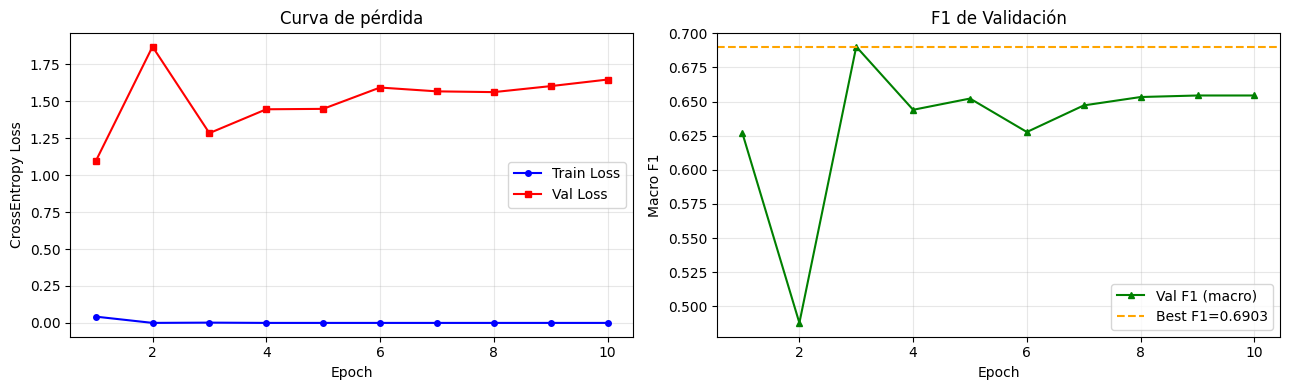

Figura guardada: training_curves.png


In [11]:
# ─── Curvas de aprendizaje ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, N_EPOCHS + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-s', ms=4, label='Val Loss')
ax1.set_title('Curva de pérdida'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('CrossEntropy Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['val_f1'], 'g-^', ms=5, label='Val F1 (macro)')
ax2.axhline(best_f1, color='orange', ls='--', label=f'Best F1={best_f1:.4f}')
ax2.set_title('F1 de Validación'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: training_curves.png')

## 6. Evaluación baseline (sin Kalman)

In [12]:
# Cargar mejor checkpoint
best_model = AnomalyDetector.load(CKPT_PATH, map_location=DEVICE)
best_model.to(DEVICE)

@torch.no_grad()
def collect_probs(model, loader, device):
    model.eval()
    probs_list, labels_list = [], []
    for X_b, y_b in loader:
        logits = model(X_b.to(device))
        p = torch.softmax(logits, -1)[:, 1].cpu().numpy()
        probs_list.extend(p.tolist())
        labels_list.extend(y_b.numpy().tolist())
    return np.array(probs_list, dtype=np.float32), np.array(labels_list, dtype=np.int64)

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'Accuracy': accuracy_score(labels, preds),
        'Recall':   recall_score(labels, preds, average='macro', zero_division=0),
        'F1':       f1_score(labels, preds, average='macro', zero_division=0),
        'MAE':      mean_absolute_error(labels, probs),
        'MSE':      mean_squared_error(labels, probs),
    }

# Recolectar probabilidades en test
test_probs, test_labels = collect_probs(best_model, test_loader, DEVICE)

baseline_metrics = compute_metrics(test_probs, test_labels)
print('── Baseline (sin Kalman) ──────────────────')
for k, v in baseline_metrics.items():
    print(f'  {k:<10}: {v:.4f}')

# Matriz de confusión
baseline_preds = (test_probs >= 0.5).astype(int)
cm = confusion_matrix(test_labels, baseline_preds)
print(f'\nMatriz de confusión:\n{cm}')
print('\nReporte de clasificación:')
print(classification_report(test_labels, baseline_preds,
                             target_names=['Normal', 'Ataque']))

── Baseline (sin Kalman) ──────────────────
  Accuracy  : 0.6857
  Recall    : 0.7054
  F1        : 0.6746
  MAE       : 0.3256
  MSE       : 0.2822

Matriz de confusión:
[[193  60]
 [182 335]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.51      0.76      0.61       253
      Ataque       0.85      0.65      0.73       517

    accuracy                           0.69       770
   macro avg       0.68      0.71      0.67       770
weighted avg       0.74      0.69      0.70       770



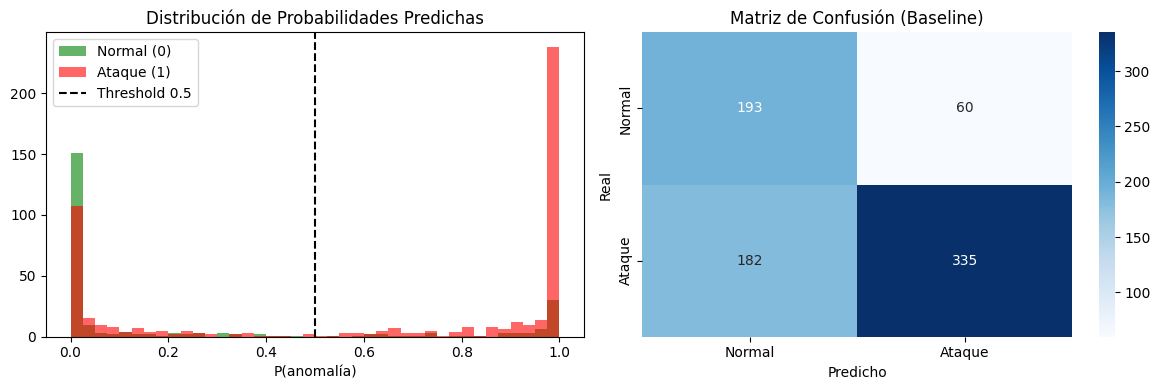

In [13]:
# Histograma de probabilidades predichas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_probs[test_labels==0], bins=40, alpha=0.6, color='green', label='Normal (0)')
axes[0].hist(test_probs[test_labels==1], bins=40, alpha=0.6, color='red',   label='Ataque (1)')
axes[0].axvline(0.5, color='black', ls='--', label='Threshold 0.5')
axes[0].set_title('Distribución de Probabilidades Predichas')
axes[0].set_xlabel('P(anomalía)'); axes[0].legend()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[1].set_title('Matriz de Confusión (Baseline)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('baseline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Filtro de Kalman

### Modelo
```
s_{t+1} = s_t + w_t,   w_t ~ N(0, σ²_w)    (caminata aleatoria)
p_t     = s_t + v_t,   v_t ~ N(0, σ²_v)    (observación ruidosa)
```

### Recursión de Kalman
**Predicción:**
- $\hat{s}_{t|t-1} = \hat{s}_{t-1|t-1}$
- $P_{t|t-1} = P_{t-1|t-1} + \sigma^2_w$

**Ganancia de Kalman:**
- $K_t = P_{t|t-1} / (P_{t|t-1} + \sigma^2_v)$

**Actualización:**
- $\hat{s}_{t|t} = \hat{s}_{t|t-1} + K_t(p_t - \hat{s}_{t|t-1})$
- $P_{t|t} = (1 - K_t)P_{t|t-1}$

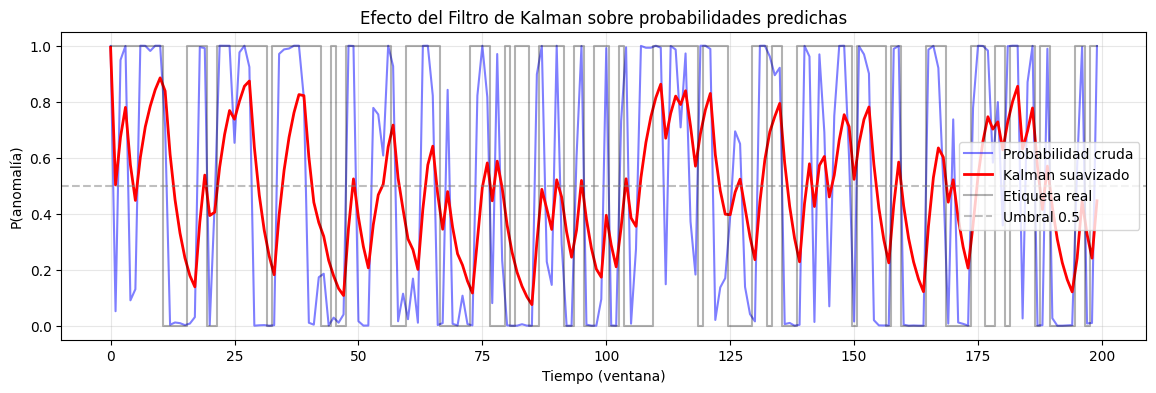

Figura guardada: kalman_effect.png


In [14]:
class KalmanSmoother:
    """
    Filtro de Kalman escalar para suavizar secuencias de probabilidad.
    
    Parámetros:
        sigma2_w: varianza del proceso (controla velocidad de cambio del estado)
        sigma2_v: varianza de observación (confianza en la red neuronal)
    """
    def __init__(self, sigma2_w: float = 1e-3, sigma2_v: float = 1e-2):
        assert sigma2_w > 0 and sigma2_v > 0, 'Las varianzas deben ser positivas'
        self.sigma2_w = sigma2_w
        self.sigma2_v = sigma2_v
        self.reset()

    def reset(self):
        self._s_hat = 0.5   # prior: máxima incertidumbre
        self._P     = 1.0

    def update(self, p_t: float) -> float:
        # Predicción
        s_pred = self._s_hat
        P_pred = self._P + self.sigma2_w
        # Ganancia
        K = P_pred / (P_pred + self.sigma2_v)
        # Actualización
        self._s_hat = s_pred + K * (p_t - s_pred)
        self._P     = (1.0 - K) * P_pred
        return float(self._s_hat)

    def smooth_sequence(self, probs):
        self.reset()
        return np.array([self.update(float(p)) for p in probs], dtype=np.float32)

    def __repr__(self):
        return f'KalmanSmoother(σ²w={self.sigma2_w:.1e}, σ²v={self.sigma2_v:.1e})'


# Demostración del filtro
ks_demo = KalmanSmoother(sigma2_w=1e-3, sigma2_v=1e-2)
smoothed_demo = ks_demo.smooth_sequence(test_probs[:200])

fig, ax = plt.subplots(figsize=(14, 4))
t = np.arange(200)
ax.plot(t, test_probs[:200],   alpha=0.5, color='blue', label='Probabilidad cruda')
ax.plot(t, smoothed_demo,     color='red', lw=2, label='Kalman suavizado')
ax.step(t, test_labels[:200], color='black', alpha=0.3, label='Etiqueta real', where='mid')
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='Umbral 0.5')
ax.set_title('Efecto del Filtro de Kalman sobre probabilidades predichas')
ax.set_xlabel('Tiempo (ventana)'); ax.set_ylabel('P(anomalía)')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('kalman_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: kalman_effect.png')

## 8. Análisis de sensibilidad Kalman

In [15]:
# Configuraciones de Kalman a evaluar
KALMAN_CONFIGS = [
    (1e-4, 1e-2),   # suavizado agresivo (σ²w muy pequeño)
    (1e-3, 1e-2),   # configuración intermedia
    (1e-2, 1e-2),   # seguimiento rápido (σ²w = σ²v)
    (1e-1, 1e-2),   # seguimiento muy rápido (σ²w >> σ²v)
    (1e-3, 1e-1),   # muy confiado en predicción (σ²v grande)
]

all_results = {}

# Baseline
all_results['Baseline (sin Kalman)'] = compute_metrics(test_probs, test_labels)

# Kalman variants
for sw, sv in KALMAN_CONFIGS:
    ks       = KalmanSmoother(sw, sv)
    smoothed = ks.smooth_sequence(test_probs)
    name     = f'Kalman(σ²w={sw:.0e}, σ²v={sv:.0e})'
    all_results[name] = compute_metrics(smoothed, test_labels)
    print(f'{name}: F1={all_results[name]["F1"]:.4f}')

# Mejor configuración
best_name = max(all_results, key=lambda k: all_results[k]['F1'])
print(f'\n→ Mejor configuración por F1: {best_name}')
print(f'  F1 = {all_results[best_name]["F1"]:.4f}')

Kalman(σ²w=1e-04, σ²v=1e-02): F1=0.5820
Kalman(σ²w=1e-03, σ²v=1e-02): F1=0.6162
Kalman(σ²w=1e-02, σ²v=1e-02): F1=0.6568
Kalman(σ²w=1e-01, σ²v=1e-02): F1=0.6758
Kalman(σ²w=1e-03, σ²v=1e-01): F1=0.5820

→ Mejor configuración por F1: Kalman(σ²w=1e-01, σ²v=1e-02)
  F1 = 0.6758


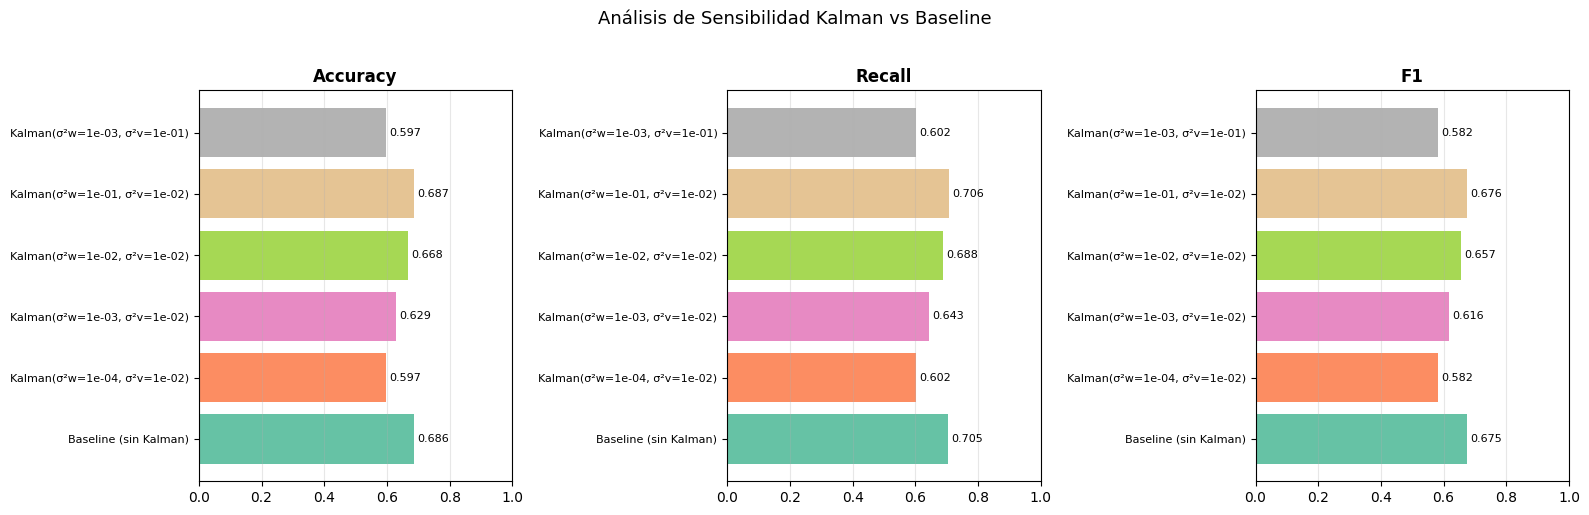

In [16]:
# Visualización del análisis de sensibilidad
names     = list(all_results.keys())
metrics   = ['Accuracy', 'Recall', 'F1', 'MAE', 'MSE']
values    = {m: [all_results[n][m] for n in names] for m in metrics}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

for ax, metric in zip(axes, ['Accuracy', 'Recall', 'F1']):
    bars = ax.barh(range(len(names)), values[metric], color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([n[:35] for n in names], fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, v in zip(bars, values[metric]):
        ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Análisis de Sensibilidad Kalman vs Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Tabla comparativa final

In [17]:
# Tabla comparativa
print('\n' + '═'*85)
print(f'  {'Variante':<42} {'Acc':>8} {'Recall':>8} {'F1':>8} {'MAE':>8} {'MSE':>8}')
print('─'*85)
for name, m in all_results.items():
    print(f"  {name:<42} {m['Accuracy']:>8.4f} {m['Recall']:>8.4f} "
          f"{m['F1']:>8.4f} {m['MAE']:>8.4f} {m['MSE']:>8.4f}")
print('═'*85)

# DataFrame para guardar
df_results = pd.DataFrame(all_results).T
df_results.index.name = 'Variante'
df_results.to_csv('results_comparison.csv', float_format='%.4f')
print('\nTabla guardada en results_comparison.csv')
df_results


═════════════════════════════════════════════════════════════════════════════════════
  Variante                                        Acc   Recall       F1      MAE      MSE
─────────────────────────────────────────────────────────────────────────────────────
  Baseline (sin Kalman)                        0.6857   0.7054   0.6746   0.3256   0.2822
  Kalman(σ²w=1e-04, σ²v=1e-02)                 0.5974   0.6023   0.5820   0.4727   0.2393
  Kalman(σ²w=1e-03, σ²v=1e-02)                 0.6286   0.6427   0.6162   0.4331   0.2349
  Kalman(σ²w=1e-02, σ²v=1e-02)                 0.6675   0.6878   0.6568   0.3695   0.2433
  Kalman(σ²w=1e-01, σ²v=1e-02)                 0.6870   0.7064   0.6758   0.3332   0.2706
  Kalman(σ²w=1e-03, σ²v=1e-01)                 0.5974   0.6023   0.5820   0.4728   0.2393
═════════════════════════════════════════════════════════════════════════════════════

Tabla guardada en results_comparison.csv


,Accuracy,Recall,F1,MAE,MSE
Variante,,,,,
Baseline (sin Kalman),0.685714,0.705407,0.674649,0.325588,0.282187
"Kalman(σ²w=1e-04, σ²v=1e-02)",0.597403,0.602304,0.581959,0.472713,0.239331
"Kalman(σ²w=1e-03, σ²v=1e-02)",0.628571,0.642671,0.616245,0.433072,0.234892
"Kalman(σ²w=1e-02, σ²v=1e-02)",0.667532,0.687831,0.656827,0.369473,0.243258
"Kalman(σ²w=1e-01, σ²v=1e-02)",0.687013,0.706375,0.675833,0.333195,0.270620
"Kalman(σ²w=1e-03, σ²v=1e-01)",0.597403,0.602304,0.581959,0.472791,0.239348


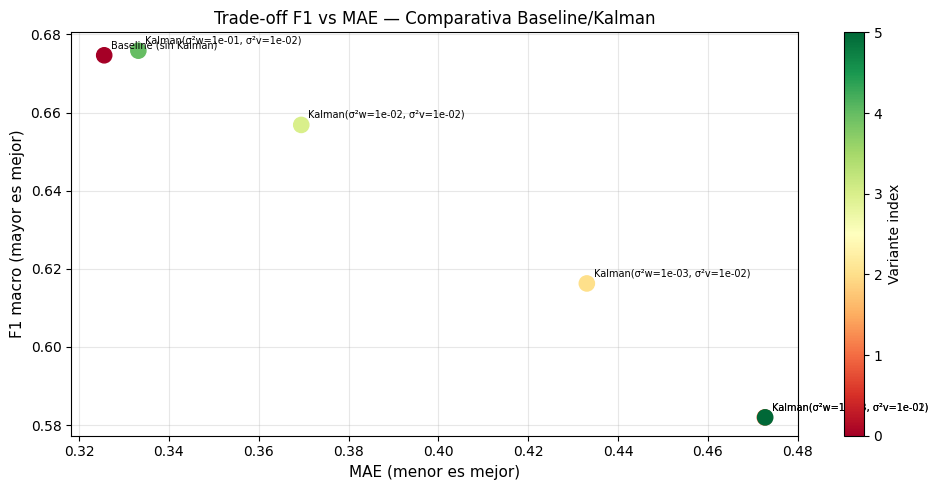

In [18]:
# Visualización comparativa F1 vs MAE
fig, ax = plt.subplots(figsize=(10, 5))

f1_vals  = [all_results[n]['F1']  for n in all_results]
mae_vals = [all_results[n]['MAE'] for n in all_results]
scatter  = ax.scatter(mae_vals, f1_vals, c=range(len(f1_vals)),
                      cmap='RdYlGn', s=120, zorder=3)

for i, n in enumerate(all_results):
    ax.annotate(n[:30], (mae_vals[i], f1_vals[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('MAE (menor es mejor)', fontsize=11)
ax.set_ylabel('F1 macro (mayor es mejor)', fontsize=11)
ax.set_title('Trade-off F1 vs MAE — Comparativa Baseline/Kalman', fontsize=12)
ax.grid(alpha=0.3)
plt.colorbar(scatter, label='Variante index')
plt.tight_layout()
plt.savefig('f1_vs_mae.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Uso programático del modelo guardado

Esta celda demuestra cómo un **usuario externo** puede cargar el modelo
entrenado y clasificar una nueva ventana.

In [19]:
# ─── Demo: cargar modelo y clasificar ventana nueva ────────────────────────

# 1. Cargar modelo desde checkpoint
model_loaded = AnomalyDetector.load('best_model.pt')
print('Modelo cargado desde checkpoint ✓')

# 2. Preparar una ventana nueva (en producción: datos reales de la red)
nueva_ventana = torch.from_numpy(
    ds_test[0][0].numpy()[np.newaxis, ...]   # (1, L, F)
)

# 3. Obtener probabilidad de anomalía
prob_anomaly = model_loaded.predict_proba(nueva_ventana)
print(f'P(anomalía) = {prob_anomaly.item():.4f}')
print(f'Clasificación: {"ATAQUE" if prob_anomaly.item() >= 0.5 else "NORMAL"}')

# 4. Aplicar filtro de Kalman sobre una secuencia
print('\n─── Con Kalman Smoother ─────────────────────────')
ks_best = KalmanSmoother(sigma2_w=1e-3, sigma2_v=1e-2)
# Suponiendo que ya tenemos una secuencia de probabilidades previas
secuencia_probs = [0.1, 0.15, 0.8, 0.85, 0.9, 0.7, 0.1, 0.05]
smoothed_seq = ks_best.smooth_sequence(secuencia_probs)
print('Probabilidades crudas  :', [f'{p:.2f}' for p in secuencia_probs])
print('Probabilidades Kalman  :', [f'{p:.2f}' for p in smoothed_seq])
print('Clasificaciones finales:', ['ATAQUE' if p>=0.5 else 'NORMAL' for p in smoothed_seq])

Modelo cargado desde checkpoint ✓
P(anomalía) = 0.9990
Clasificación: ATAQUE

─── Con Kalman Smoother ─────────────────────────
Probabilidades crudas  : ['0.10', '0.15', '0.80', '0.85', '0.90', '0.70', '0.10', '0.05']
Probabilidades Kalman  : ['0.10', '0.13', '0.39', '0.54', '0.65', '0.66', '0.50', '0.38']
Clasificaciones finales: ['NORMAL', 'NORMAL', 'NORMAL', 'ATAQUE', 'ATAQUE', 'ATAQUE', 'ATAQUE', 'NORMAL']


In [20]:
print('=' * 60)
print('  PROYECTO COMPLETADO')
print('=' * 60)
print(f'  Checkpoint: best_model.pt')
print(f'  Resultados: results_comparison.csv')
print(f'  Mejor F1  : {max(m["F1"] for m in all_results.values()):.4f}')
print()
print('  Archivos generados:')
for f in ['best_model.pt', 'results_comparison.csv',
          'training_curves.png', 'baseline_evaluation.png',
          'kalman_effect.png', 'sensitivity_analysis.png',
          'class_distribution.png', 'f1_vs_mae.png']:
    exists = Path(f).exists()
    print(f'    {"✓" if exists else "✗"} {f}')

  PROYECTO COMPLETADO
  Checkpoint: best_model.pt
  Resultados: results_comparison.csv
  Mejor F1  : 0.6758

  Archivos generados:
    ✓ best_model.pt
    ✓ results_comparison.csv
    ✓ training_curves.png
    ✓ baseline_evaluation.png
    ✓ kalman_effect.png
    ✓ sensitivity_analysis.png
    ✓ class_distribution.png
    ✓ f1_vs_mae.png
